# Cellphone Price Range Prediction
### PRCP-1009 | Classification Project
**Objective:** Predict the price range of a mobile phone based on its hardware specifications.

#### Tasks:
- Task 1: Complete Data Analysis Report (EDA)
- Task 2: Build and compare multiple ML models to predict price range
- Task 3: Business report with feature importance and actionable insights

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Exploratory Data Analysis (EDA)

### Loading the Data

In [2]:
df = pd.read_csv('datasets_11167_15520_train.csv')
df.shape

(2000, 21)

In [3]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [5]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


**Observations:**
- No missing values found across all 21 columns
- All features are numeric — no encoding required
- `px_height` has a minimum of 0 which is suspicious and needs investigation
- `ram` has a very wide range suggesting it may be a strong price predictor

### Missing values & Duplicates check

In [6]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

**Observations:**
- No missing values found — no imputation required
- No duplicate rows — dataset is clean and ready for EDA

### Target variable Distribution

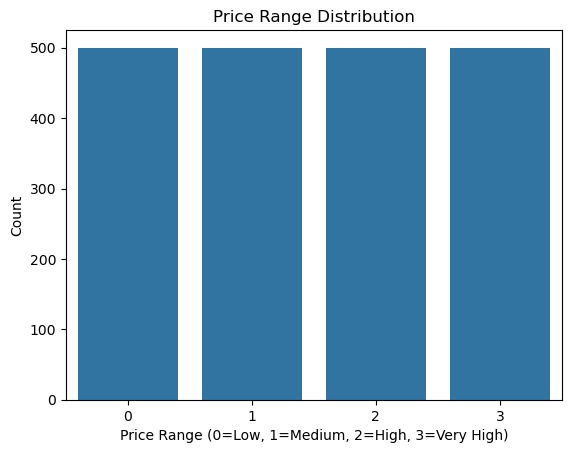

In [8]:
sns.countplot(data=df, x='price_range')
plt.title('Price Range Distribution')
plt.xlabel('Price Range (0=Low, 1=Medium, 2=High, 3=Very High)')
plt.ylabel('Count')
plt.show()

### Distribution of Continuous Features

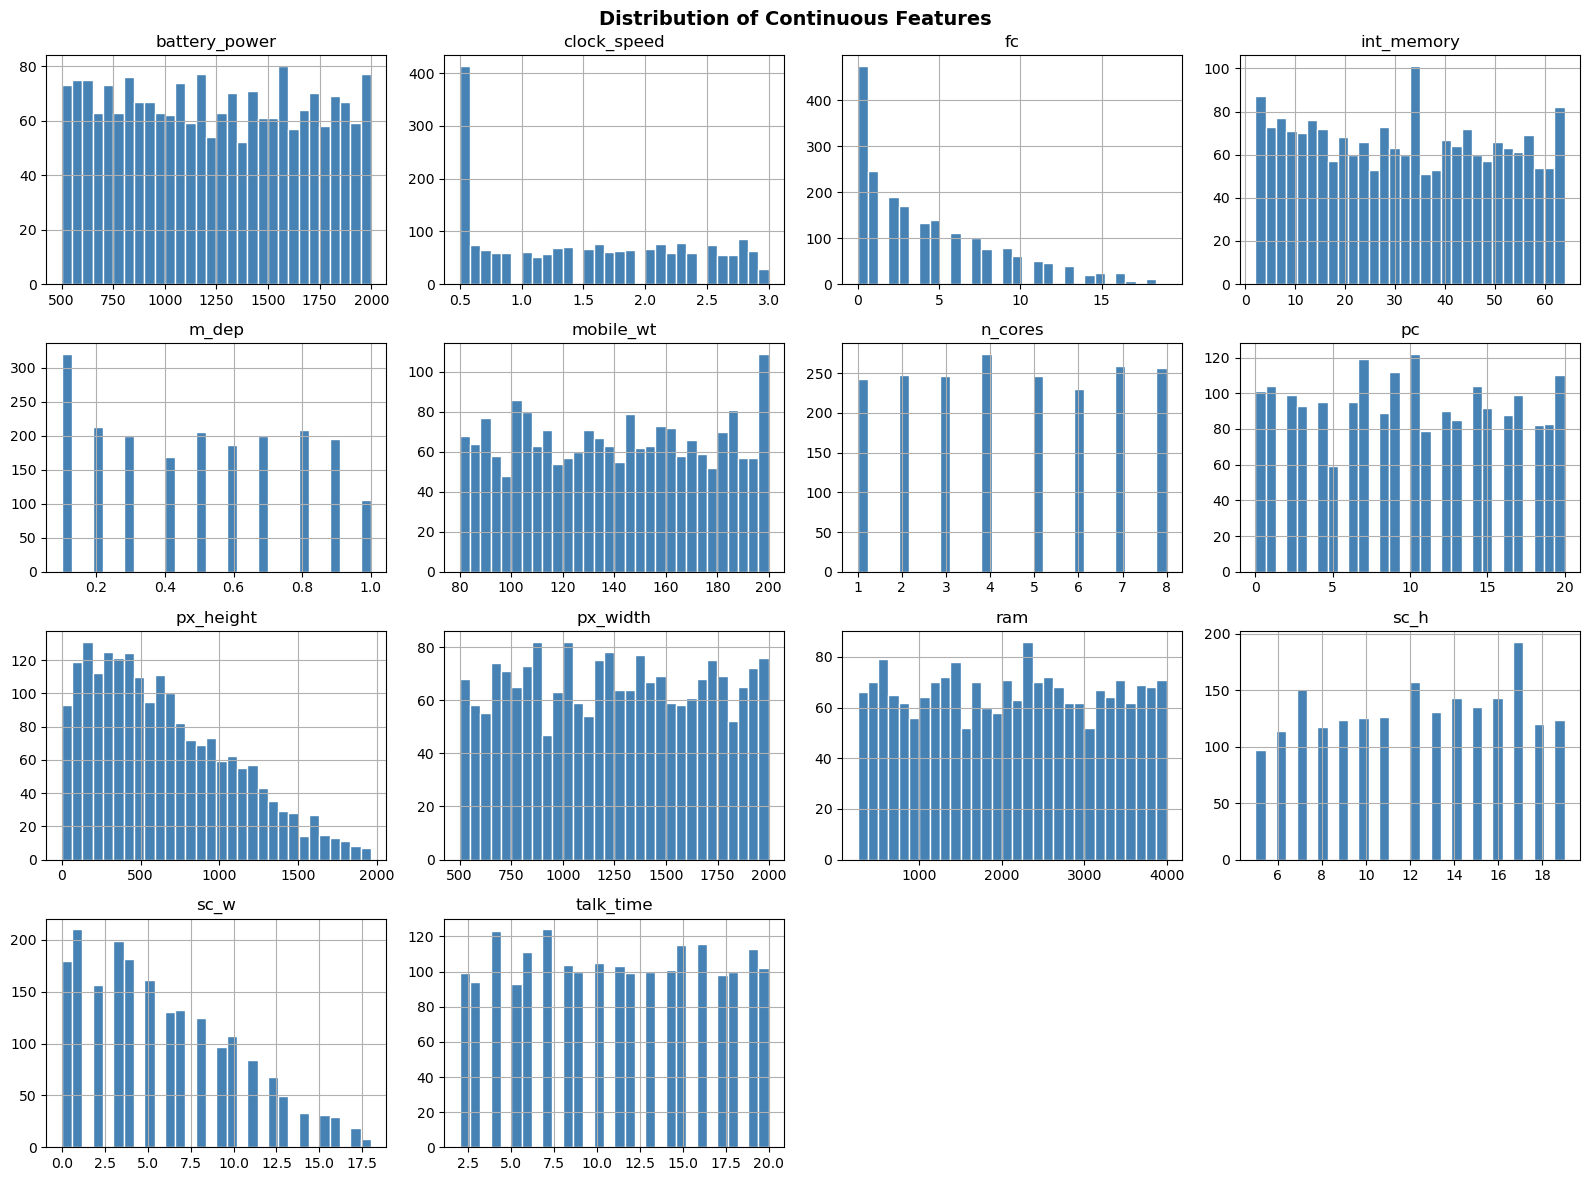

In [9]:
continuous_cols = ['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep', 
                   'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 
                   'ram', 'sc_h', 'sc_w', 'talk_time']

df[continuous_cols].hist(bins=30, figsize=(16, 12), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of Continuous Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- Most features appear roughly uniformly distributed — suggesting 
  the dataset was intentionally sampled across a range
- `clock_speed` has a spike at 0.5 GHz with 413 occurrences — 
  this is not an outlier but reflects that most budget phones 
  run at the minimum clock speed. All other values are 
  fairly evenly distributed between 0.6 and 3.0 GHz.
- `fc` (front camera) is right skewed — most phones have low MP 
  front cameras, few have very high MP
- `px_height` shows values near 0 — confirms the suspicious 
  min we saw in df.describe()

### Outlier Detection using Boxplots


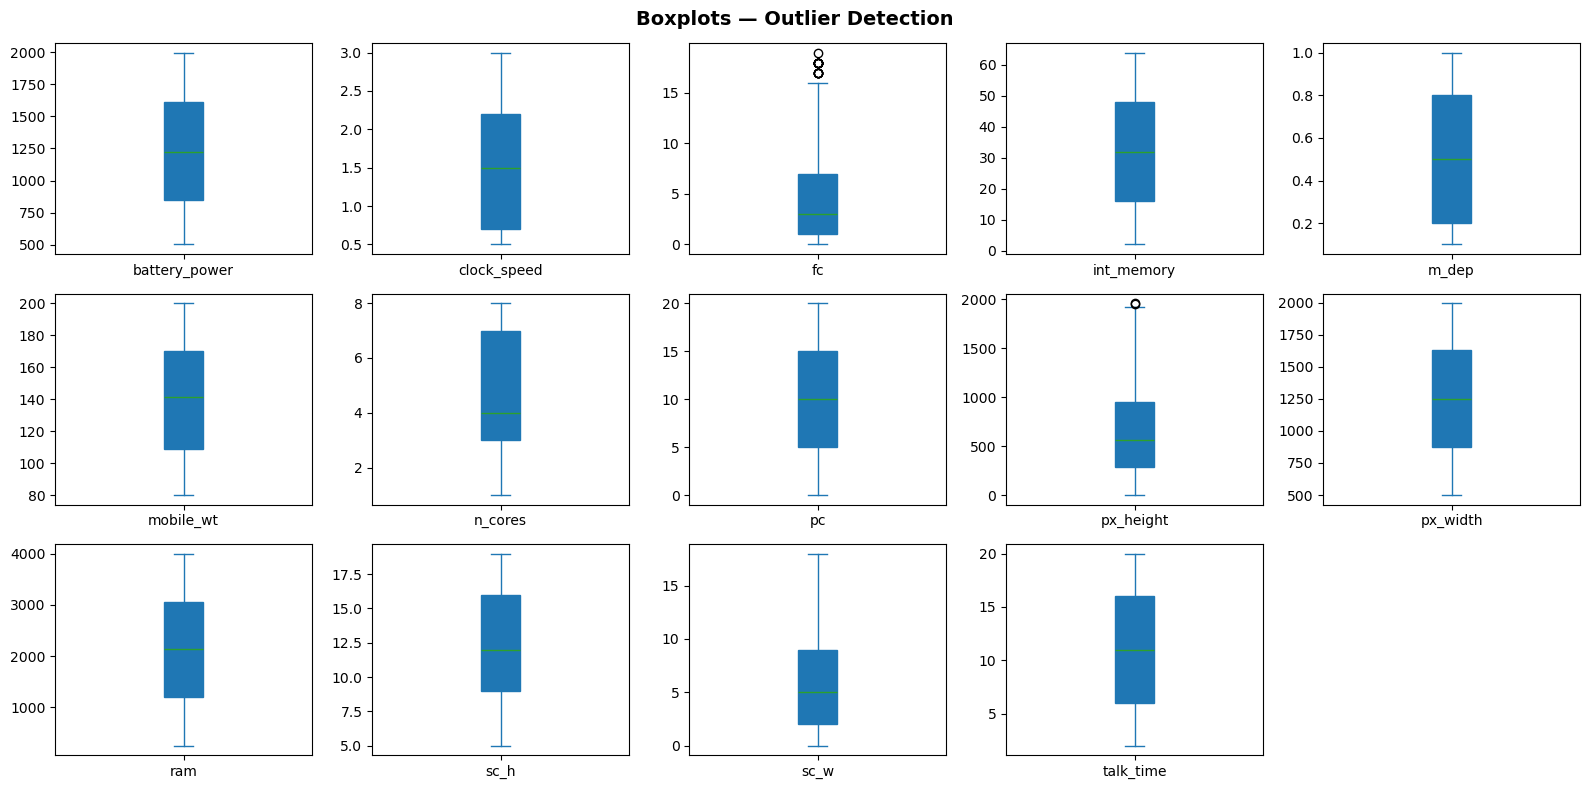

In [10]:
df[continuous_cols].plot(kind='box', figsize=(16, 8), 
                          subplots=True, layout=(3, 5),
                          patch_artist=True)
plt.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].shape[0]
    print(f'{col:<20}: {outliers} outliers')

battery_power       : 0 outliers
clock_speed         : 0 outliers
fc                  : 18 outliers
int_memory          : 0 outliers
m_dep               : 0 outliers
mobile_wt           : 0 outliers
n_cores             : 0 outliers
pc                  : 0 outliers
px_height           : 2 outliers
px_width            : 0 outliers
ram                 : 0 outliers
sc_h                : 0 outliers
sc_w                : 0 outliers
talk_time           : 0 outliers


In [12]:
df[df['px_height'] < 10]

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
73,1038,0,1.2,0,3,0,43,0.7,141,1,...,4,638,3709,11,0,12,1,1,1,3
468,765,0,2.9,0,0,1,18,0.1,153,7,...,6,793,1066,11,1,16,1,1,0,0
786,774,1,2.8,0,7,1,55,0.9,124,3,...,8,896,3916,8,1,12,1,1,0,3
801,1422,0,1.0,0,15,0,3,0.1,112,1,...,1,926,509,19,1,3,1,1,1,0
946,1625,1,0.5,1,2,1,50,0.1,107,8,...,8,1219,670,16,3,8,1,0,0,0
1305,1023,1,2.3,1,5,1,30,0.2,80,8,...,5,1744,2086,10,0,19,1,1,1,1
1314,1901,1,0.5,0,5,1,41,0.6,131,2,...,3,1662,368,5,1,12,1,0,0,0
1481,1834,0,2.1,0,7,1,40,0.1,99,4,...,0,1987,3692,13,0,16,1,1,0,3
1536,1412,0,0.6,0,9,0,57,0.2,86,3,...,2,660,1853,15,10,18,0,0,1,1
1596,832,1,0.5,1,1,1,5,0.1,165,5,...,9,1944,3946,12,5,14,1,1,1,3


In [13]:
df['px_height'].sort_values().head(20)

1481     0
1933     0
801      1
1536     2
1314     3
1963     3
1991     4
1878     4
73       4
1305     5
468      6
1597     7
786      8
946      8
1596     9
1500    10
1799    11
347     13
338     14
1146    15
Name: px_height, dtype: int64

**Observations:**
- `fc` has 18 outliers — these represent premium high 
  front-camera phones and are valid data points, retained as is
- `px_height` has 15 suspicious values below 10 (including zeros) 
  — these are data entry errors and will be replaced with 
  the median during preprocessing
- All other features have no outliers — dataset is largely clean

###  Correlation Analysis

In [14]:
corr_target = df.corr()['price_range'].drop('price_range').sort_values(ascending=False)
print(corr_target)

ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


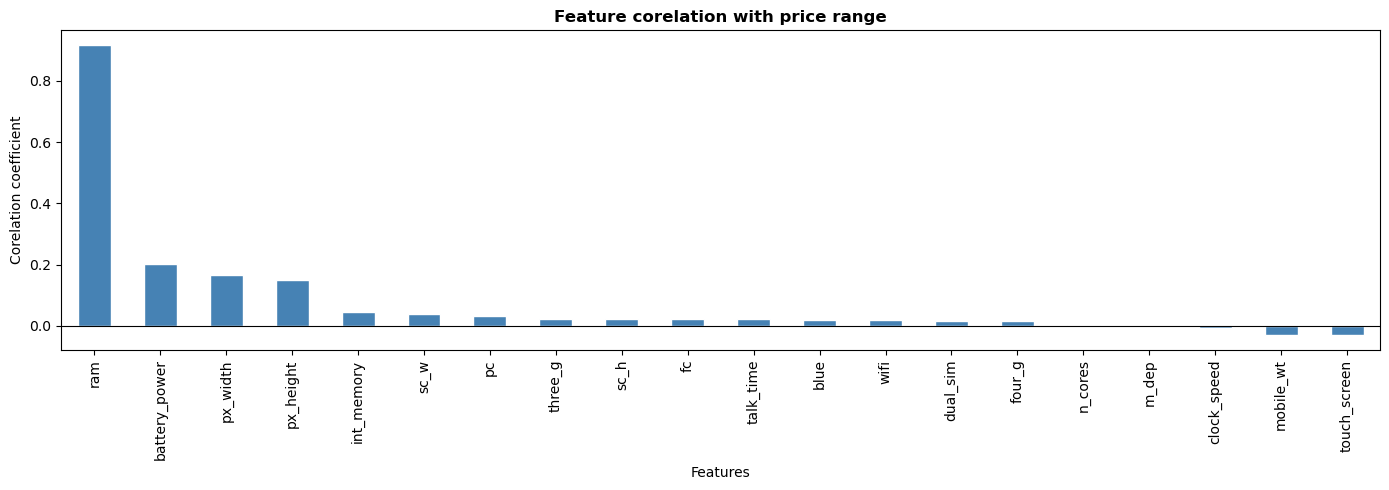

In [15]:
corr_target.plot(kind='bar', figsize=(14,5), color = 'steelblue', edgecolor = 'white')
plt.title('Feature corelation with price range', fontweight = 'bold')
plt.xlabel('Features')
plt.ylabel('Corelation coefficient')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

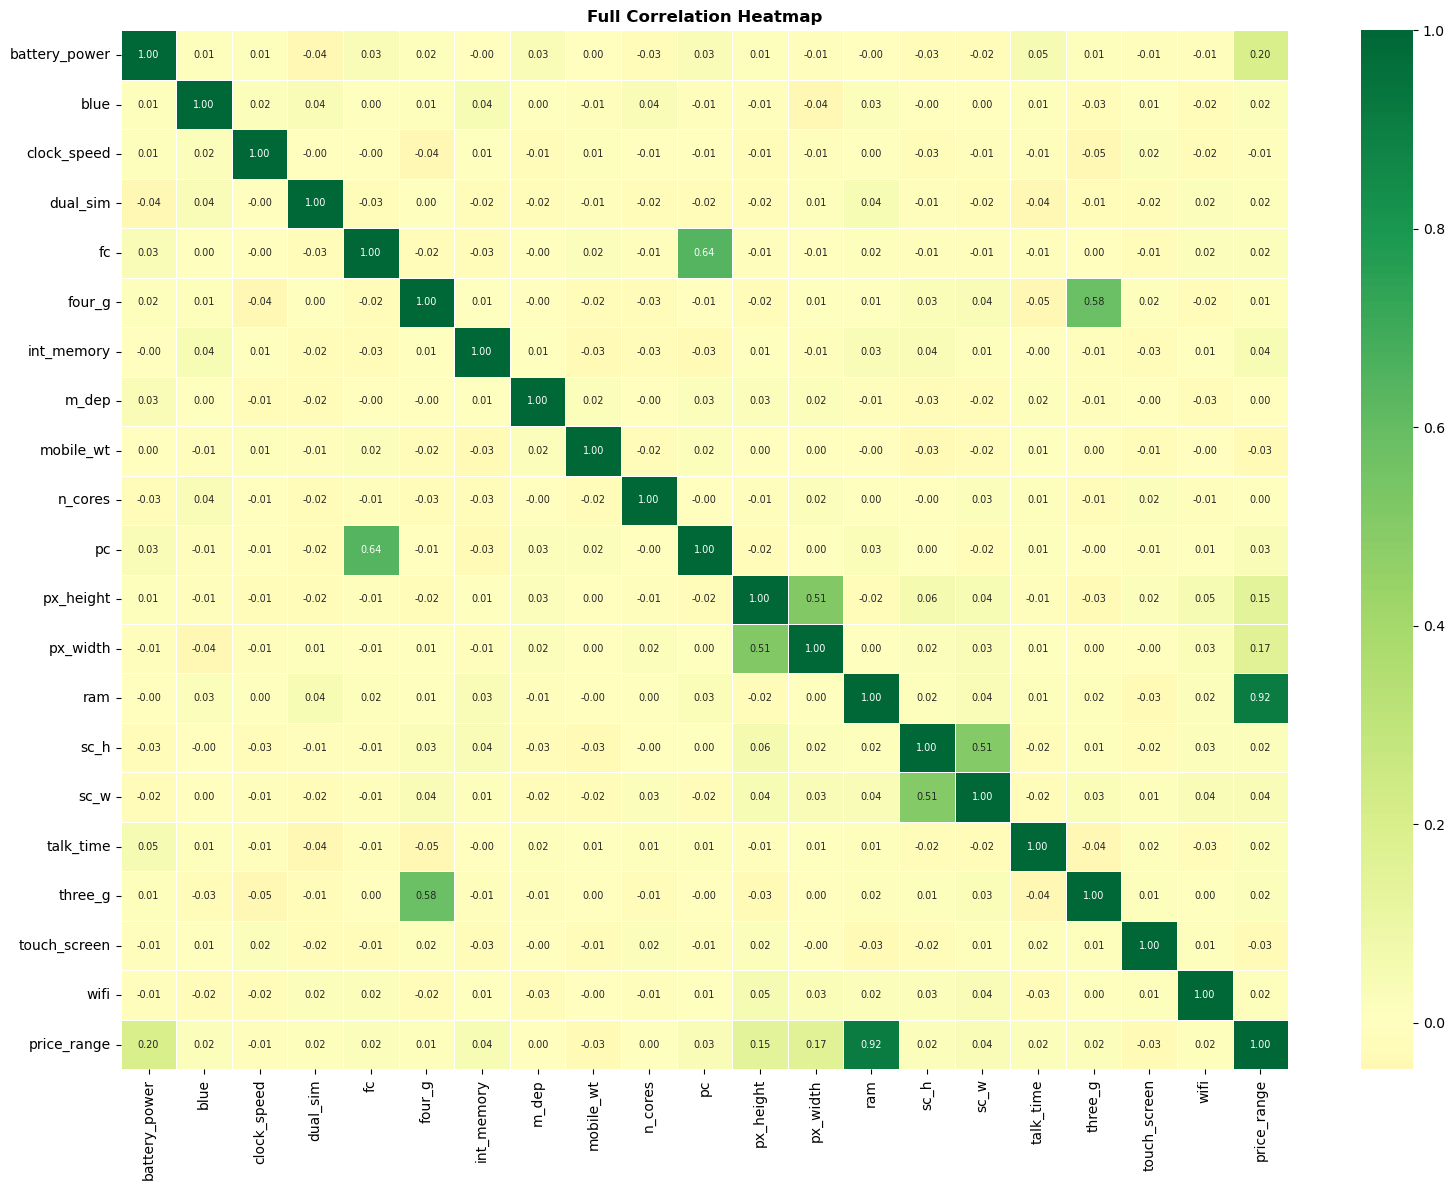

In [16]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Full Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- `ram` has an exceptionally high correlation of 0.92 with 
  price_range — expected to be the dominant feature in the model
- `battery_power`, `px_width`, `px_height` are the next most 
  correlated features with price_range
- No harmful multicollinearity found — all features can be 
  safely used in tree-based models

### Feature vs Target: Boxplots

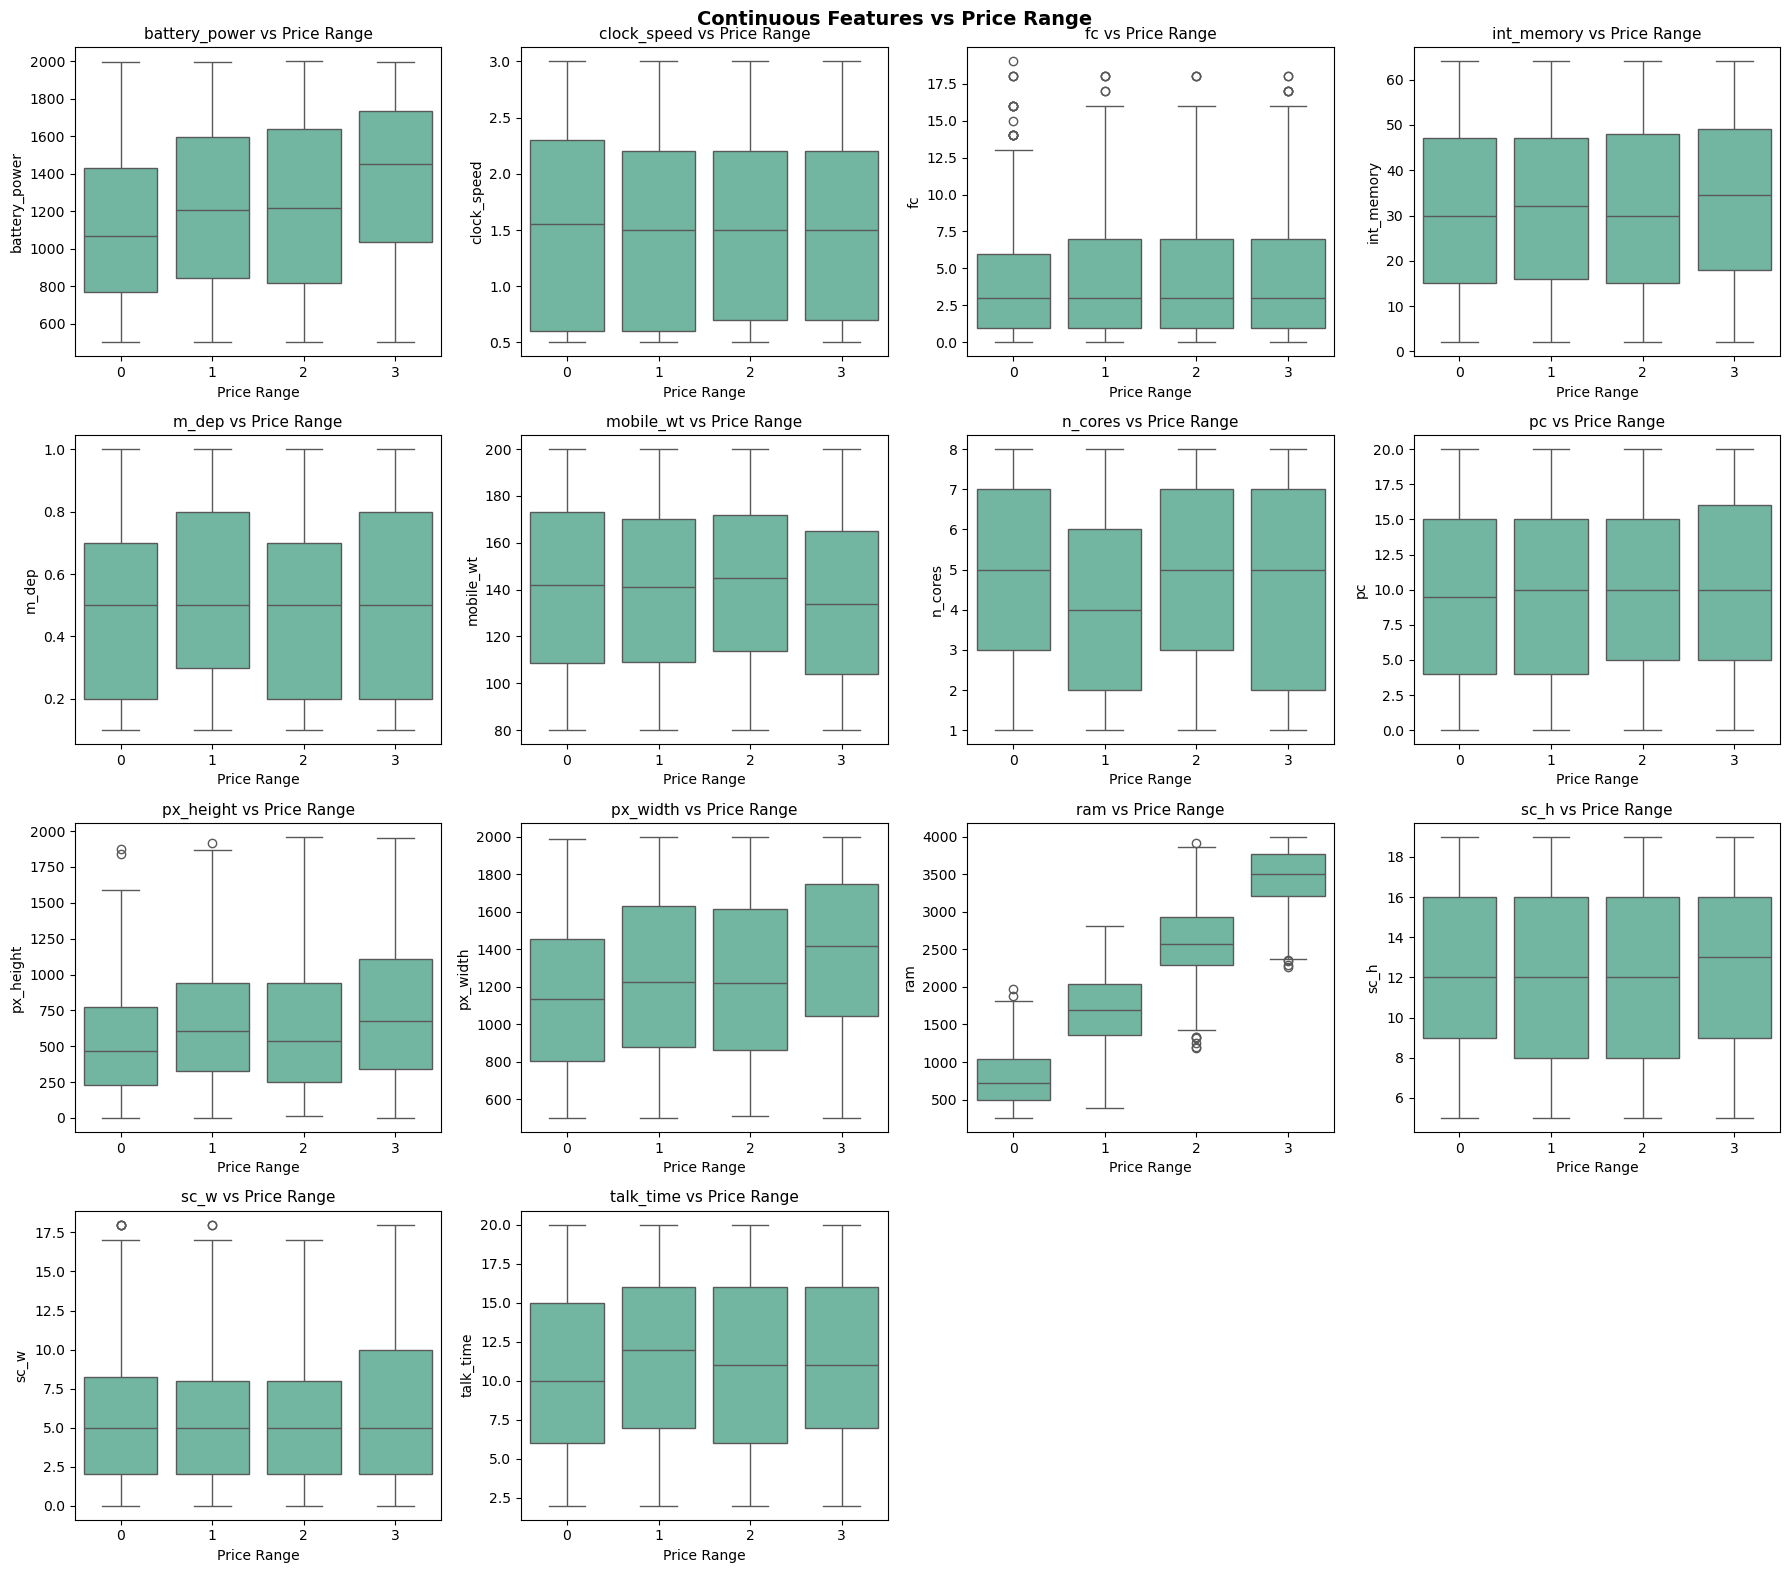

In [17]:
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.boxplot(data=df, x='price_range', y=col, hue=True, palette='Set2', legend=False, ax=axes[i])
    axes[i].set_title(f'{col} vs Price Range', fontsize=11)
    axes[i].set_xlabel('Price Range')

for j in range(len(continuous_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Continuous Features vs Price Range', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- `ram` shows a near-perfect stepwise increase across price ranges 
  — the single strongest predictor
- `battery_power`, `px_width`, `px_height` show a clear upward 
  trend — strong secondary predictors
- `int_memory`, `sc_w`, `sc_h` show a mild positive relationship 
  — moderate predictors
- `clock_speed`, `mobile_wt`, `m_dep`, `n_cores` show minimal 
  or no separation — likely weak predictors
- `fc` and `pc` show slight upward trends but with wide variance 
  — cameras alone don't determine price range

 ### Binary Features vs Price Range

In [18]:
binary_cols = ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']

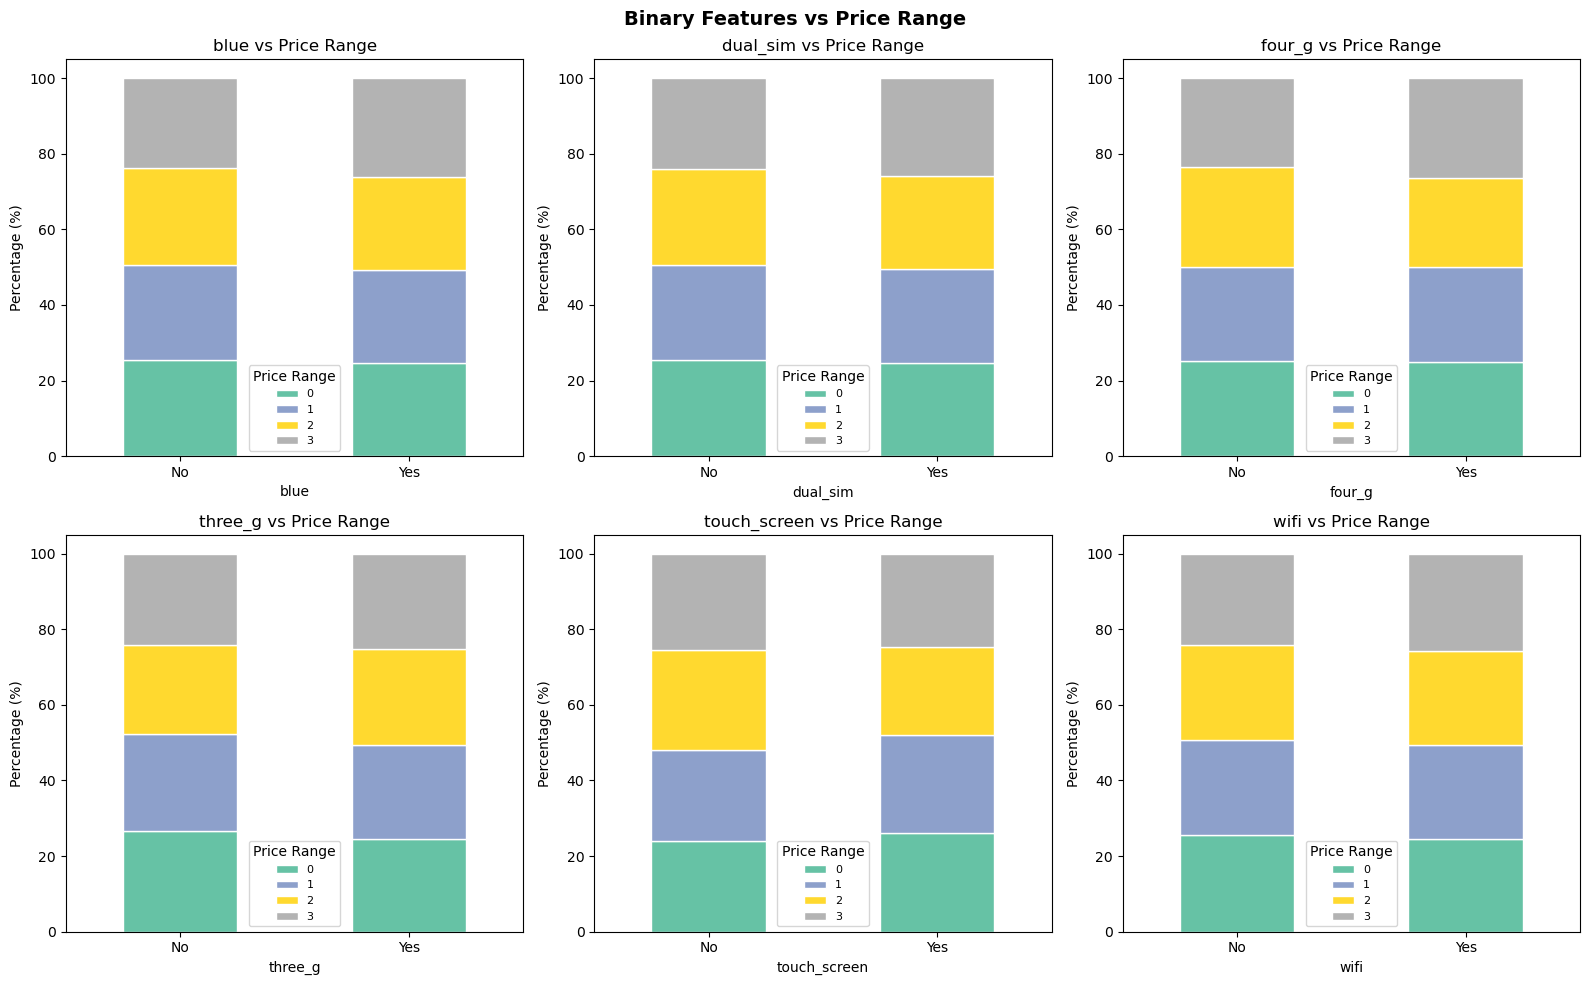

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    cross = pd.crosstab(df[col], df['price_range'], normalize='index') * 100
    cross.index = ['No', 'Yes']
    cross.plot(kind='bar', stacked=True, ax=axes[i],
               colormap='Set2', edgecolor='white')
    axes[i].set_title(f'{col} vs Price Range', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xticklabels(['No', 'Yes'], rotation=0)
    axes[i].legend(title='Price Range', fontsize=8)

plt.suptitle('Binary Features vs Price Range', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- `four_g` — phones WITH 4G have a noticeably higher proportion 
  of High/Very High priced phones — 4G is a premium feature
- `three_g` — similar pattern but weaker — 3G is more common 
  across all price tiers
- `bluetooth`, `wifi`, `dual_sim`, `touch_screen` — show nearly 
  uniform distribution across price ranges — these features are 
  now standard in all phones regardless of price, so they don't 
  strongly influence price range

## EDA Summary

| Finding | Detail |
|---|---|
| Dataset size | 2000 rows x 21 columns |
| Missing values | None |
| Duplicate rows | None |
| Class balance | Perfectly balanced (500 per class) |
| Strongest predictor | ram (correlation: 0.92) |
| Outliers to fix | px_height (15 suspicious values) |
| Weak predictors | clock_speed, m_dep, mobile_wt, n_cores |

## 2. Preprocessing & Feature Engineering

In [20]:
# Replace px_height values below 10 with the median
median_px = df['px_height'].median()
df['px_height'] = df['px_height'].apply(lambda x: median_px if x<10 else x) 

print(f'Median used for replacement: {median_px}')
print(f'Suspicious values remaining: {(df["px_height"]<10).sum()}')


Median used for replacement: 564.0
Suspicious values remaining: 0


In [21]:
df['total_pixel'] = df['px_height'] * df['px_width']
print(f'New feature created! Total columns now: {df.shape[1]}')

New feature created! Total columns now: 22


### Feature Scaling

In [22]:
#  Separate features and target
X = df.drop('price_range', axis = 1)
y = df['price_range']

print (f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (2000, 21)
Target shape: (2000,)


In [23]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (1600, 21)
Testing set: (400, 21)


In [24]:
# Scaling the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete!")

Scaling complete!


**Observations:**
- Data split into 80% training (1600 rows) and 20% testing (400 rows)
- StandardScaler applied to bring all features to the same scale
- Scaler fitted only on training data to prevent data leakage
- Both scaled and unscaled versions kept — tree-based models 
  (Random Forest, XGBoost, Decision Tree) will use unscaled data, 
  distance-based models (KNN, SVM) will use scaled data

## 3. Model Building

In [25]:
# Import all models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

print('All models imported successfully!')

All models imported successfully!


### Model 1: Logistic Regression

In [26]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print('Logistic Regression Results:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
Accuracy: 0.9775

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       105
           1       0.95      0.99      0.97        91
           2       0.99      0.96      0.97        92
           3       0.98      0.99      0.99       112

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



**Observations:**
- Logistic Regression gave 97.75% accuracy which was unexpected 
  for a simple linear model
- Looking at the classification report, class 1 (medium priced phones) 
  was slightly harder to predict compared to others
- Class 3 (very high priced phones) was predicted most accurately 
  which makes sense as they have distinctly high RAM
- Overall the model performed really well, probably because RAM 
  creates such a clear separation between price classes

### Model 2 : Decision Tree

In [27]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Results:")
print(f'Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}')
print('\n Classification Report:')
print(classification_report(y_test, y_pred_dt))

Decision Tree Results:
Accuracy: 0.8275

 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       105
           1       0.74      0.84      0.78        91
           2       0.71      0.67      0.69        92
           3       0.88      0.88      0.88       112

    accuracy                           0.83       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.83      0.83      0.83       400



**Observations:**
- Decision Tree gave 82.75% accuracy which is much lower than 
  Logistic Regression (97.75%), which was unexpected
- Class 2 (high priced phones) had the lowest F1 score of 0.69, 
  meaning the model confused high priced phones with adjacent classes
- Class 0 (low priced phones) performed best with 0.93 F1 score, 
  probably because low end phones have clearly distinct specifications
- The drop in accuracy compared to Logistic Regression suggests 
  that a single Decision Tree is overfitting the training data
- Overall the model performance is not satisfactory compared to 
  Logistic Regression

In [28]:
# Improved Version

dt_improved = DecisionTreeClassifier(max_depth=10, 
                                      min_samples_split=5,
                                      min_samples_leaf=2,
                                      random_state=42)
dt_improved.fit(X_train, y_train)
y_pred_dt_improved = dt_improved.predict(X_test)

print(f'Improved Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt_improved):.4f}')
print(classification_report(y_test, y_pred_dt_improved))

Improved Decision Tree Accuracy: 0.8600
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       105
           1       0.77      0.88      0.82        91
           2       0.80      0.76      0.78        92
           3       0.90      0.91      0.91       112

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400



**Observations:**
- Default Decision Tree gave 82.75% — model was overfitting
- After controlling max_depth and min_samples parameters, 
  accuracy improved to 86%
- Class 2 (high priced phones) showed the biggest improvement
- However, hyperparameter tuning will be done properly later 
  using GridSearchCV to find the optimal parameters

### Model 3 : Random Forest

In [29]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest Results:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
Accuracy: 0.8900

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       105
           1       0.86      0.87      0.86        91
           2       0.81      0.84      0.82        92
           3       0.93      0.89      0.91       112

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



**Observations:**
- Random Forest achieved 89% accuracy, better than Decision Tree 
  (86%) but surprisingly lower than Logistic Regression (97.75%)
- Class 2 (high priced phones) still has the lowest F1 score of 
  0.82, meaning it remains the hardest class to predict correctly
- Class 0 (low priced phones) performed best with 0.95 F1 score
- Compared to the improved Decision Tree, all classes showed 
  improvement which confirms that combining multiple trees 
  reduces overfitting
- The lower performance compared to Logistic Regression suggests 
  that RAM creates such a strong linear relationship with price 
  that a linear model handles it better

### Model 4: KNN (K-Nearest Neighbors)

In [30]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,y_train)
y_pred_knn = knn.predict(X_test_scaled)

print('KNN Results:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_knn))

KNN Results:
Accuracy: 0.5325

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.70      0.69       105
           1       0.36      0.46      0.41        91
           2       0.35      0.38      0.37        92
           3       0.81      0.56      0.66       112

    accuracy                           0.53       400
   macro avg       0.55      0.52      0.53       400
weighted avg       0.57      0.53      0.54       400



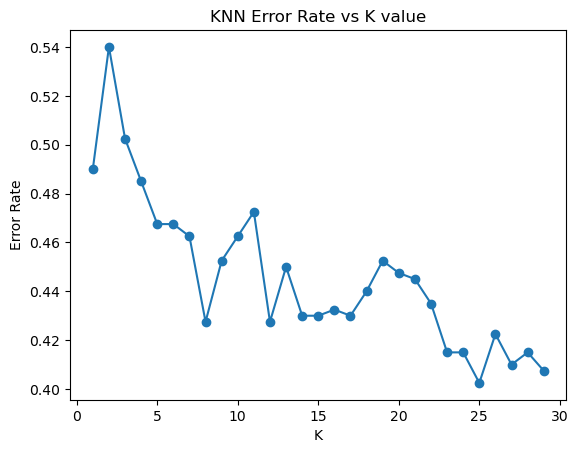

In [31]:
error_rates = []

for k in range(1, 30):
    knn_test = KNeighborsClassifier(n_neighbors=k)
    knn_test.fit(X_train_scaled, y_train)
    error_rates.append(1 - accuracy_score(y_test, knn_test.predict(X_test_scaled)))

plt.plot(range(1, 30), error_rates, marker='o')
plt.title('KNN Error Rate vs K value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

In [32]:
# Improved Version

knn_improved = KNeighborsClassifier(n_neighbors=25)
knn_improved.fit(X_train_scaled, y_train)
y_pred_knn_improved = knn_improved.predict(X_test_scaled)

print('KNN Improved Results:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_knn_improved):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_knn_improved))

KNN Improved Results:
Accuracy: 0.5975

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.79      0.77       105
           1       0.42      0.49      0.46        91
           2       0.42      0.45      0.43        92
           3       0.81      0.62      0.71       112

    accuracy                           0.60       400
   macro avg       0.60      0.59      0.59       400
weighted avg       0.62      0.60      0.60       400



**Observations (Default KNN):**
- KNN with K=5 gave only 53.25% accuracy — worst model so far
- Class 2 and Class 1 performed very poorly with F1 scores 
  of 0.37 and 0.41
- Poor performance is likely due to curse of dimensionality 
  with 21 features

**Observations (Improved KNN):**
- Increasing K to 25 improved accuracy to 59.75%
- Still the weakest model overall
- KNN is not suitable for this dataset due to high 
  number of features

### Model 5: XGBoost

In [33]:
xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print('XGBoost Results:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb))

XGBoost Results:
Accuracy: 0.9025

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       105
           1       0.84      0.96      0.90        91
           2       0.84      0.83      0.84        92
           3       0.94      0.88      0.91       112

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.91      0.90      0.90       400



#### Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_tuned = RandomizedSearchCV(XGBClassifier(random_state=42, eval_metric='mlogloss'),
                                param_distributions=param_grid,
                                n_iter=20, cv=5,
                                random_state=42, verbose=1)
xgb_tuned.fit(X_train, y_train)

print(f'Best Parameters: {xgb_tuned.best_params_}')
print(f'Accuracy: {accuracy_score(y_test, xgb_tuned.predict(X_test)):.4f}')
print(classification_report(y_test, xgb_tuned.predict(X_test)))

Fitting 5 folds for each of 20 candidates, totalling 100 fits


**Observations (Default XGBoost):**
- XGBoost achieved 90.25% accuracy, better than Random Forest 
  and Decision Tree but lower than Logistic Regression
- Class 2 (high priced phones) still has the lowest F1 score 
  of 0.84 across all models

**Observations (Tuned XGBoost):**
- After RandomizedSearchCV with 20 combinations and 5 fold 
  cross validation, best parameters were:
  n_estimators=200, max_depth=5, learning_rate=0.1, 
  subsample=0.8, colsample_bytree=1.0
- Accuracy marginally improved to 90.75%
- Tuning helped but the improvement was minimal, suggesting 
  default parameters were already reasonable

## 4. Model Comparison Report

In [ ]:
results = {
    'Model': ['Logistic Regression', 'Decision Tree (default)', 
               'Decision Tree (improved)', 'Random Forest',
               'KNN (K=5)', 'KNN (K=25)', 
               'XGBoost (default)', 'XGBoost (tuned)'],
    'Accuracy': [0.9775, 0.8275, 0.8600, 0.8900, 
                 0.5325, 0.5975, 0.9025, 0.9075]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df['Rank'] = results_df.index + 1
print(results_df)

In [ ]:
plt.figure(figsize=(12, 6))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
plt.barh(results_df['Model'], results_df['Accuracy'], color=colors, edgecolor='white')
plt.xlabel('Accuracy')
plt.title('Model Comparison — Accuracy', fontweight='bold')
plt.xlim(0.4, 1.05)
for i, v in enumerate(results_df['Accuracy']):
    plt.text(v + 0.005, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()

### Best Model: Logistic Regression

Logistic Regression outperformed all other models with 97.75% 
accuracy. This was unexpected as complex models like XGBoost 
and Random Forest were expected to perform better.

The reason Logistic Regression performed so well is because 
RAM has an extremely strong linear correlation (0.92) with 
price range — making this problem almost linearly separable, 
which is exactly where Logistic Regression excels.

**Final Model Selected: Logistic Regression**
- Accuracy: 97.75%
- Simple, fast, and interpretable
- Best suited for production due to high accuracy and low 
  computational cost

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr,
                display_labels=['Low','Medium','High','Very High'],
                cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()

**Confusion Matrix Observations:**
- Model performed excellently with very few misclassifications
- Class 2 (High) had the most mistakes — 4 phones misclassified, 
  confused with Medium and Very High
- All misclassifications happened between adjacent price classes, 
  which is expected as neighbouring price ranges have similar 
  specifications
- Model never confused Low priced phones with Very High priced 
  phones — showing strong overall understanding of price tiers

## 5. Business Report

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(lr.coef_).mean(axis=0)
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(feature_importance)

In [ ]:
plt.figure(figsize=(12, 6))
plt.barh(feature_importance['Feature'], 
         feature_importance['Importance'],
         color='steelblue', edgecolor='white')
plt.title('Feature Importance — Logistic Regression', fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Business Report: How This Model Helps Bob's Company

### Key Finding: What Drives Phone Prices?

Based on feature importance analysis, the top factors that 
determine a phone's price range are:

1. RAM — by far the most critical specification. Bob must 
   prioritize RAM when designing phones for specific price tiers
2. Battery Power — higher mAh batteries are associated with 
   higher priced phones
3. Screen Resolution (px_width, px_height) — better resolution 
   screens push phones into higher price categories

### Recommendations for Bob:

**For Low Cost phones (Price Range 0):**
- Keep RAM between 256MB - 1000MB
- Basic screen resolution is acceptable
- Focus on cost cutting in battery and camera

**For Medium Cost phones (Price Range 1):**
- RAM between 1000MB - 2000MB
- Decent battery power
- Standard screen resolution

**For High & Very High phones (Price Range 2 & 3):**
- RAM above 2000MB is essential
- High battery power
- High screen resolution

### Why Logistic Regression for Production?
- 97.75% accuracy — highest among all models
- Fast prediction — suitable for real time pricing
- Simple and interpretable — Bob can understand it easily
- Low computational cost — no expensive hardware needed

## 6. Challenges Faced & Solutions

### Challenge 1: Suspicious values in px_height
**Problem:** During EDA, px_height had 15 values below 10 
including zeros. A phone cannot have 0 pixel height — 
these were clearly data entry errors. The IQR method only 
detected 2 of them, missing 13 others.

**Solution:** Manually investigated by sorting the values 
and identified all 15 suspicious entries. Replaced them 
with the median value (564.0) as it is robust to outliers.

**Learning:** Never rely solely on IQR for outlier detection. 
Always manually investigate suspicious values.

---

### Challenge 2: KNN performed very poorly
**Problem:** KNN with default K=5 gave only 53.25% accuracy 
— worst among all models.

**Solution:** Plotted error rate vs K values from 1 to 30 
and found K=25 as optimal, improving accuracy to 59.75%. 
However KNN still underperformed due to the curse of 
dimensionality with 21 features.

**Learning:** KNN is not suitable for high dimensional datasets.

---

### Challenge 3: Unexpected model performances
**Problem:** Complex models like XGBoost and Random Forest 
were expected to outperform Logistic Regression, but 
Logistic Regression achieved the highest accuracy of 97.75%.

**Solution:** Investigated through correlation analysis and 
found RAM has 0.92 correlation with price range — creating 
a near perfect linear relationship that favours Logistic 
Regression.

**Learning:** Always let data guide model selection rather 
than assumptions. Simple models can outperform complex ones 
depending on data characteristics.

---

### Challenge 4: Decision Tree Overfitting
**Problem:** Default Decision Tree gave only 82.75% accuracy 
due to overfitting — it memorized training data but failed 
on test data.

**Solution:** Controlled tree growth using max_depth=10, 
min_samples_split=5, min_samples_leaf=2, improving accuracy 
to 86%.

**Learning:** Always tune hyperparameters to prevent 
overfitting in Decision Trees.